In [11]:
import pandas as pd
import collections
import bz2
import gzip
from urllib.request import urlopen
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_list = [
	"/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_100k.markdup.sorted_CpG.bedGraph",
	"/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_200k.markdup.sorted_CpG.bedGraph"
]
id_list = ["Healthy_1_100k","Healthy_1_200k"]
file_id_df = pd.DataFrame.from_dict({
		"id": id_list,
		"file": file_list
	})
file_id_df

,id,file
0,Healthy_1_100k,/efs/scratch/jeffrey/code/github.com/exosomedx...
1,Healthy_1_200k,/efs/scratch/jeffrey/code/github.com/exosomedx...


In [9]:
def read_bedfile(fname:str):
    '''
    read compressed (.gz .bz) BED files
    From https://github.com/liguowang/cpgtools/blob/master/lib/cpgmodule/ireader.py
    cpgtools version 1.10.0
    Used with chrom_count_from_bedfile function
    '''

    def nopen(f, mode="rb"):
        if not isinstance(f, str):
            return f
        if f.startswith("|"):
            p = Popen(f[1:], stdout=PIPE, stdin=PIPE, shell=True)
            if mode[0] == "r": return p.stdout
            return p
        return {"r": sys.stdin, "w": sys.stdout}[mode[0]] if f == "-" \
            else gzip.open(f, mode) if f.endswith((".gz", ".Z", ".z")) \
            else bz2.BZ2File(f, mode) if f.endswith((".bz", ".bz2", ".bzip2")) \
            else urlopen(f) if f.startswith(("http://", "https://","ftp://")) \
            else open(f, mode)

    for l in nopen(fname):
        yield l.decode('utf8').strip().replace("\r", "")

In [3]:
def cpg_count_from_bedfile(infile:str) -> dict:
    '''
    count chrom frequencies from BED file
    From https://github.com/liguowang/cpgtools/blob/master/lib/cpgmodule/utils.py
    cpgtools version 1.10.0
    '''
    
    
    chrom_count = collections.defaultdict(int)
    
    for l in read_bedfile(infile):
        if l.startswith('#'):
            continue
        if l.startswith('track'):
            continue
        if l.startswith('browser'):
            continue
        f = l.split()
        if len(f)< 3:
            print ("BED has at least 3 columns. Skip: " + l, file=sys.stderr)
            continue
        try:
            start = int(f[1])
            end = int(f[2])
            if start > end:
                print ("'Start' cannot be larger than 'End'. Skip: " + l, file=sys.stderr)
                continue
        except:
            print ("Not in valid BED format. Skip:" + l, file=sys.stderr)
            continue

        chrom_count[f[0]] += 1
    return chrom_count

def meth_count_from_bedfile(infile:str) -> dict:
    '''
    count methylation on each chromosome from BED file
    Modified from https://github.com/liguowang/cpgtools/blob/master/lib/cpgmodule/utils.py
    cpgtools version 1.10.0
    '''
    
    
    chrom_count = collections.defaultdict(int)
    
    for l in read_bedfile(infile):
        if l.startswith('#'):
            continue
        if l.startswith('track'):
            continue
        if l.startswith('browser'):
            continue
        f = l.split()
        if len(f)< 3:
            print("BED has at least 3 columns. Skip: " + l, file=sys.stderr)
            continue
        try:
            start = int(f[1])
            end = int(f[2])
            if start > end:
                print("'Start' cannot be larger than 'End'. Skip: " + l, file=sys.stderr)
                continue
        except:
            print("Not in valid BED format. Skip:" + l, file=sys.stderr)
            continue

        # Counts any partially or fully methylated CpG.
        if float(f[3]) > 0:
            chrom_count[f[0]] += 1

    return chrom_count


In [4]:
def meth_histogram_by_chromosome(hg38_chrom_sizes_file:str,
	file_id_df:pd.DataFrame) -> (pd.DataFrame, pd.DataFrame):
	'''
    Calculate chromosome-level CpG methylation statistics. Returns one Pandas DataFrame that is raw methylation counts and one that is percentage of CpGs.

    '''
	
	keep_chr_names = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX',  'chrY', 'chrM']
	control_chr_names = ['phage_lambda', 'plasmid_puc19c']
	chr_size_df = pd.read_csv(hg38_chrom_sizes_file, sep='\t', index_col=0, header=None)
	chr_size_df.columns = ['chr_length']
	chr_size_df.index.name = 'chromosome'

	cpg_countsL = []
	meth_countsL = []

	control_cpg_countsL = []
	control_meth_countsL = []

	for index, row in file_id_df.iterrows():
		rep = row["id"]

		cpg_count = cpg_count_from_bedfile(row["file"])
		cpg_count_df = pd.DataFrame(data={rep+'_cpg':[cpg_count[q] for q in keep_chr_names]}, index=keep_chr_names)
		meth_count = meth_count_from_bedfile(row["file"])
		meth_count_df = pd.DataFrame(data={rep+'_meth':[meth_count[q] for q in keep_chr_names]}, index=keep_chr_names)
		cpg_countsL.append(cpg_count_df)
		meth_countsL.append(meth_count_df)

		control_cpg_count_df = pd.DataFrame(data={rep+'_cpg':[cpg_count[q] for q in control_chr_names]}, index=control_chr_names)
		control_meth_count_df = pd.DataFrame(data={rep+'_meth':[meth_count[q] for q in control_chr_names]}, index=control_chr_names)
		control_cpg_countsL.append(control_cpg_count_df)
		control_meth_countsL.append(control_meth_count_df)
	
	cpg_counts_df = pd.concat(cpg_countsL, axis=1)
	meth_counts_df = pd.concat(meth_countsL, axis=1)
	counts_df = pd.concat([meth_counts_df, cpg_counts_df], axis=1)
    # counts_df.to_csv(mfreq_path_fn)

	control_cpg_counts_df = pd.concat(control_cpg_countsL, axis=1)
	control_meth_counts_df = pd.concat(control_meth_countsL, axis=1)
	control_counts_df = pd.concat([control_meth_counts_df, control_cpg_counts_df], axis=1)
    # control_counts_df.to_csv(mfreq_control_path_fn)

	counts_df_meth = counts_df.filter(like='_meth', axis=1)
	count_col_names = [q[:-5] for q in counts_df_meth.columns]
	counts_df_meth.columns = count_col_names

	counts_df_cpg = counts_df.filter(like='_cpg', axis=1)
	count_col_names = [q[:-4] for q in counts_df_cpg.columns]
	counts_df_cpg.columns = count_col_names

	counts_df_long = counts_df_meth.reset_index().melt(id_vars='index', var_name = "replicate", value_name='count')
	cpg_df_long = counts_df_cpg.reset_index().melt(id_vars='index', var_name = "replicate", value_name='count')

	control_counts_df_meth = control_counts_df.filter(like='_meth', axis=1)
	count_col_names = [q[:-5] for q in control_counts_df_meth.columns]
	control_counts_df_meth.columns = count_col_names
    
	control_counts_df_cpg = control_counts_df.filter(like='_cpg', axis=1)
	count_col_names = [q[:-4] for q in control_counts_df_cpg.columns]
	control_counts_df_cpg.columns = count_col_names
    
	control_counts_df_long = control_counts_df_meth.reset_index().melt(id_vars='index', var_name = "replicate", value_name='count')
	control_cpg_df_long = control_counts_df_cpg.reset_index().melt(id_vars='index', var_name = "replicate", value_name='count')
    
	counts_df_long = pd.concat([counts_df_long, control_counts_df_long])
	cpg_df_long = pd.concat([cpg_df_long, control_cpg_df_long])

	chr_iteration_list = keep_chr_names + control_chr_names
	# Calculate the percentage of methylation and return a DF with methylated CpG counts, all CpG counts, and percent methylated.
	chr_percentL = []
	for this_chr_name in chr_iteration_list:
		this_cpg_counts = cpg_df_long.where(counts_df_long.loc[:,'index'].eq(this_chr_name)).dropna()
		this_meth_counts = counts_df_long.where(counts_df_long.loc[:,'index'].eq(this_chr_name)).dropna()

		this_chr_pct = this_meth_counts.loc[:,'count'].div(this_cpg_counts.loc[:,'count']).mul(100).reset_index(drop=True)
		# If a zero is in the denominator it means there was zero methylation percent.
		this_chr_pct = this_chr_pct.fillna(0)
		this_chr_pct.name = 'Percent CpGs Methylated'

		this_chr_name_df = this_cpg_counts.loc[:,'index'].reset_index(drop=True)
		this_chr_name_df.name = 'Chromosome'

		this_chr_sample = this_cpg_counts.loc[:,'replicate'].reset_index(drop=True)
		this_chr_sample.name = 'Sample'

		this_chr_cpg_counts = this_cpg_counts.loc[:,'count'].reset_index(drop=True)
		this_chr_cpg_counts.name = 'CpG Count'

		this_chr_meth_counts = this_cpg_counts.loc[:,'count'].reset_index(drop=True)
		this_chr_meth_counts.name = 'Methylated CpG Count'

		this_chr_df = pd.concat([this_chr_sample, this_chr_name_df, this_chr_meth_counts, this_chr_cpg_counts, this_chr_pct], axis=1)
		chr_percentL.append(this_chr_df)
	chr_percent_df = pd.concat(chr_percentL)
	return counts_df_long, chr_percent_df






In [16]:
def output_chromosome_histograms(counts_df_long:pd.DataFrame, chr_percent_df:pd.DataFrame, histogram_dims:(float,float) = (8,4), histogram_xaxis_label_rotation:float = 45) -> None:
	'''
	counts_df_long: Pandas DataFrame containing columns named index, count, and replicate. index is chromosome.
	chr_percent_df: Same as above except it is percent methylated CpGs.
	These objects are created by the function meth_histogram_by_chromosome()
	'''
	f,ax = plt.subplots(figsize=histogram_dims)
	# sns.barplot(data=counts_df_long, y='count', x='index', hue='replicate', palette='Set2');
	sns.barplot(data=chr_percent_df, y='CpG Count', x='Chromosome', hue='Sample', palette='Set2');
	sns.despine()
	plt.xticks(rotation=histogram_xaxis_label_rotation, ha='right')
	plt.legend(bbox_to_anchor=(1,1));
	plt.savefig("meth_histogram_by_chromosome_CpG_count.png")

	f,ax = plt.subplots(figsize=histogram_dims)
	sns.barplot(data=chr_percent_df, y='Percent CpGs Methylated', x='Chromosome', hue='Sample', palette='Set2');
	sns.despine()
	plt.xticks(rotation=histogram_xaxis_label_rotation, ha='right')
	plt.legend(bbox_to_anchor=(1,1));
	plt.savefig("meth_histogram_by_chromosome_Percent_CpGs.png")
# Chromosome-Level Histogram Plotting ##########

In [13]:
counts_df_long, chr_percent_df = meth_histogram_by_chromosome("s3://exosomedx/pipeline_resources/references/methylation/hg38.chrom.sizes",file_id_df)

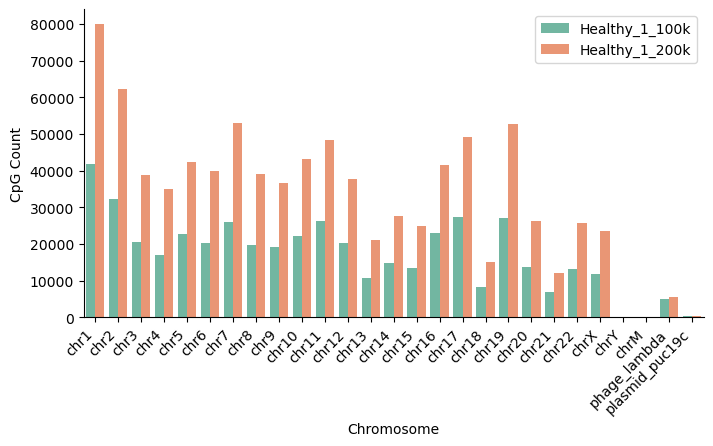

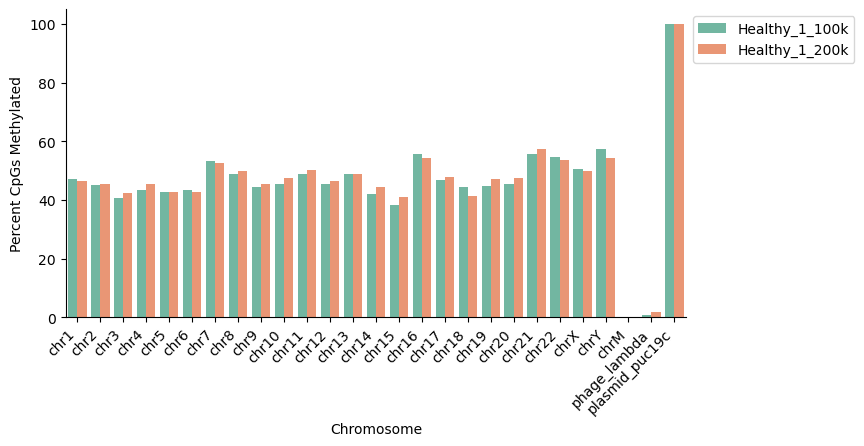

In [17]:
output_chromosome_histograms(counts_df_long, chr_percent_df)